<a href="https://colab.research.google.com/github/coderKC1999/Fashion_MNIST/blob/main/Fashion_MNIST_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FashinMNIST | CNN | Pytorch
**by CoderKC1999**

In [2]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [ ]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

In [ ]:
batch_size = 32

# Dataloader creation
train_dataloader = DataLoader(train_data, batch_size=batch_size,shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size,shuffle=True)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([32, 1, 28, 28])
Shape of y: torch.Size([32]) torch.int64


In [ ]:
# Checking Device type
print(torch.accelerator.is_available())
print(torch.accelerator.current_accelerator().type)


True
cuda


In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
# Define Model

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x
CNN_model = CNN().to(device)
print(CNN_model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


**Optimizing the Model Parameters**

In [ ]:
from torch.optim import optimizer

loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from tqdm.auto import tqdm

model = CNN_model

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        progress_bar = tqdm(dataloader, total=len(dataloader), desc="Training", unit="batch")

        # Prediction Error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update progress bar with current loss and completion %
        progress_bar.set_postfix(loss=f"{loss.item():>7f}")

        # if batch % 1000 == 0:
        #     loss, current = loss.item(), (batch + 1) * len(X)
        #     print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()

    test_loss, correct = 0,0
    with torch.no_grad():
      for X,y in dataloader:
        X,y = X.to(device), y.to(device)
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
from tqdm.auto import tqdm

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()

    progress_bar = tqdm(dataloader, total=len(dataloader), desc="Training", unit="batch")

    for batch, (X, y) in enumerate(progress_bar):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        progress_bar.set_postfix(loss=f"{loss.item():>7f}")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()

    test_loss, correct = 0,0
    with torch.no_grad():
      for X,y in dataloader:
        X,y = X.to(device), y.to(device)
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------


Training:   0%|          | 0/1875 [00:00<?, ?batch/s]

Test Error: 
 Accuracy: 88.3%, Avg loss: 0.321017 

Epoch 2
-------------------------------


Training:   0%|          | 0/1875 [00:00<?, ?batch/s]

Test Error: 
 Accuracy: 88.9%, Avg loss: 0.296432 

Epoch 3
-------------------------------


...

Test Error: 
 Accuracy: 90.4%, Avg loss: 0.256886 

Epoch 4
-------------------------------


Training:   0%|          | 0/1875 [00:00<?, ?batch/s]

Test Error: 
 Accuracy: 91.1%, Avg loss: 0.244776 

Epoch 5
-------------------------------


Training:   0%|          | 0/1875 [00:00<?, ?batch/s]

Test Error: 
 Accuracy: 91.4%, Avg loss: 0.240482 

Done!


In [ ]:
torch.save(model.state_dict(), "Ptu1c2_CNN_Model_5epoch.pth")
print("Saved PyTorch Model State to Ptu1c2_CNN_Model_5epoch.pth")

Saved PyTorch Model State to Ptu1c2_CNN_Model_5epoch.pth


In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc


In [ ]:
evaluate(model, test_dataloader)

Test Accuracy: 91.37%


91.37

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def CM_eval(model, loader, classes):
    model.eval()
    all_pred = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_pred.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_pred)

    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')

    return cm

array([[865,   0,  20,   7,   2,   1,  98,   0,   7,   0],
       [  2, 976,   0,  17,   3,   0,   1,   0,   1,   0],
       [ 13,   1, 894,   5,  34,   0,  51,   0,   2,   0],
       [ 26,   2,  18, 893,  24,   0,  36,   0,   1,   0],
       [  0,   0,  78,  22, 847,   0,  53,   0,   0,   0],
       [  0,   0,   0,   0,   0, 984,   0,  13,   0,   3],
       [ 97,   1,  68,  16,  65,   0, 747,   0,   6,   0],
       [  0,   0,   0,   0,   0,   6,   0, 978,   0,  16],
       [  3,   1,   3,   1,   1,   1,   1,   1, 988,   0],
       [  0,   0,   0,   0,   0,   6,   1,  28,   0, 965]])

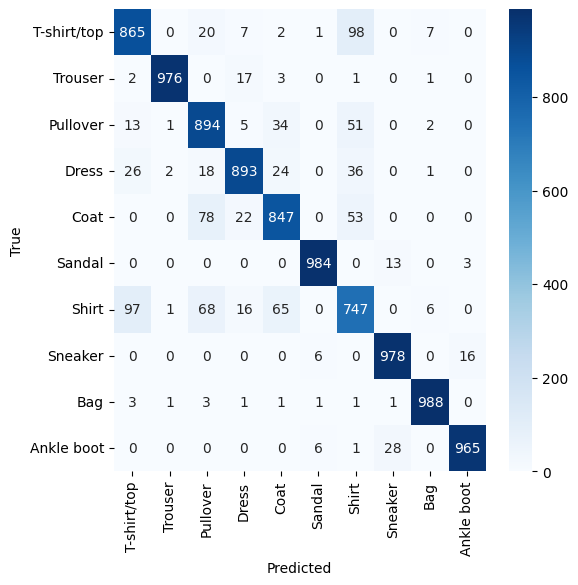

In [ ]:
CM_eval(model, test_dataloader, classes)